# Impulse Control Predictor for Online Shopping
## Machine Learning Project - Complete ML Pipeline

**Goal:** Predict whether a customer will make an impulsive purchase based on behavioral and transactional features.

**Dataset:** ecommerce_customer_churn_dataset.csv

### Project Overview:
1. Load and explore the dataset
2. Engineer features based on impulse purchase indicators
3. Create the target variable using Impulse Control Index (ICI)
4. Train multiple ML models
5. Evaluate and compare models
6. Extract feature importance
7. Explain predictions using SHAP
8. Save the trained model for production

---

## STEP 1: Environment Setup and Library Imports

In [1]:
# Install required packages for Google Colab
import subprocess
import sys

packages = ['xgboost', 'shap', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']

print("Installing required packages...")
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("✓ All packages installed successfully!")

Installing required packages...
✓ All packages installed successfully!


In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, confusion_matrix, classification_report,
                            roc_curve)
import xgboost as xgb
import pickle

# SHAP for model explainability
import shap

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")
print("\nLibrary Versions:")
print(f"  - pandas: {pd.__version__}")
print(f"  - numpy: {np.__version__}")
print(f"  - scikit-learn: {pd.__version__}")
print(f"  - xgboost: {xgb.__version__}")
print(f"  - shap: {shap.__version__}")
print(f"  - matplotlib: {matplotlib.__version__}")

✓ All libraries imported successfully!

Library Versions:
  - pandas: 2.3.3
  - numpy: 2.3.4
  - scikit-learn: 2.3.3
  - xgboost: 3.2.0
  - shap: 0.50.0
  - matplotlib: 3.10.8


## STEP 2: Load and Explore Dataset

**Note:** If running in Google Colab, you can upload your CSV file or use the sample dataset generator below.

In [3]:
# Generate sample dataset (in case original dataset is not available)
def create_sample_dataset(n_samples=1000):
    """Generate a realistic sample e-commerce dataset"""
    np.random.seed(42)
    
    data = {
        'customer_id': np.arange(1, n_samples + 1),
        'total_time_spent': np.random.uniform(30, 600, n_samples),  # seconds
        'number_of_clicks': np.random.randint(1, 50, n_samples),
        'add_to_cart_time': np.random.uniform(0.5, 30, n_samples),  # minutes
        'discount_percentage': np.random.uniform(0, 70, n_samples),
        'purchase_flag': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'purchase_time': np.random.randint(0, 24, n_samples),  # hour of day
        'device_type': np.random.choice(['Mobile', 'Desktop', 'Tablet'], n_samples, p=[0.5, 0.35, 0.15]),
        'previous_purchases': np.random.randint(0, 30, n_samples),
        'customer_age': np.random.randint(18, 70, n_samples),
        'product_category': np.random.choice(['Electronics', 'Fashion', 'Home', 'Sports', 'Beauty'], n_samples),
    }
    
    return pd.DataFrame(data)

# Load or create dataset
try:
    # Try to load from file (works when dataset is in working directory)
    if os.path.exists('data/ecommerce_customer_churn_dataset.csv'):
        df = pd.read_csv('data/ecommerce_customer_churn_dataset.csv')
        print("✓ Dataset loaded from file!")
    else:
        # Create sample dataset
        df = create_sample_dataset(n_samples=1000)
        print("✓ Sample dataset created! (Use your own dataset for better results)")
except:
    # Create sample dataset
    df = create_sample_dataset(n_samples=1000)
    print("✓ Sample dataset created!")

import os

print(f"\nDataset Shape: {df.shape}")
print(f"  - Rows: {df.shape[0]}")
print(f"  - Columns: {df.shape[1]}")

✓ Sample dataset created!

Dataset Shape: (1000, 11)
  - Rows: 1000
  - Columns: 11


In [4]:
# Display dataset summary
print("\n" + "="*80)
print("DATASET OVERVIEW")
print("="*80)

print("\nFirst 5 rows:")
print(df.head())

print("\n" + "-"*80)
print("Data Types:")
print("-"*80)
print(df.dtypes)

print("\n" + "-"*80)
print("Statistical Summary:")
print("-"*80)
print(df.describe())


DATASET OVERVIEW

First 5 rows:
   customer_id  total_time_spent  number_of_clicks  add_to_cart_time  \
0            1        243.487868                47         29.237857   
1            2        571.907155                12          1.090777   
2            3        447.236547                16         22.246817   
3            4        371.235336                24         23.173694   
4            5        118.930625                19          7.687873   

   discount_percentage  purchase_flag  purchase_time device_type  \
0            19.490759              1             21     Desktop   
1             9.072046              1             23      Mobile   
2            47.327576              1              6      Mobile   
3            66.078761              1              7     Desktop   
4            18.827762              1             18      Mobile   

   previous_purchases  customer_age product_category  
0                  19            60             Home  
1              

In [5]:
# Check for missing values
print("\n" + "="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0]

if len(missing_data) == 0:
    print("\n✓ No missing values found!")
else:
    print("\n" + missing_data.to_string(index=False))

# Handle missing values (if any)
print("\n" + "-"*80)
print("Handling Missing Values...")
print("-"*80)

# For numerical columns, use median
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# For categorical columns, use mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("✓ Missing values handled successfully!")
print(f"Remaining missing values: {df.isnull().sum().sum()}")


MISSING VALUES ANALYSIS

✓ No missing values found!

--------------------------------------------------------------------------------
Handling Missing Values...
--------------------------------------------------------------------------------
✓ Missing values handled successfully!
Remaining missing values: 0


## STEP 3: Feature Engineering

Create domain-specific features based on impulse purchase behavior:
- **session_speed**: Time per click (lower = quick browsing)
- **urgency_score**: Quick add-to-cart action
- **discount_sensitivity**: Response to discounts
- **night_purchase_flag**: Late-night purchases
- **mobile_user_flag**: Mobile device usage

In [6]:
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Feature 1: Session Speed (time per click)
print("\n1. Creating Session Speed...")
df['session_speed'] = np.where(
    df['number_of_clicks'] > 0,
    df['total_time_spent'] / df['number_of_clicks'],
    0
)
print(f"   ✓ Mean: {df['session_speed'].mean():.2f} sec/click")

# Feature 2: Urgency Score
print("\n2. Creating Urgency Score...")
df['urgency_score'] = (df['add_to_cart_time'] < 2).astype(int)
print(f"   ✓ Quick add-to-cart purchases: {df['urgency_score'].sum()} ({df['urgency_score'].mean()*100:.1f}%)")

# Feature 3: Discount Sensitivity
print("\n3. Creating Discount Sensitivity...")
df['discount_sensitivity'] = np.where(
    df['purchase_flag'] == 1,
    df['discount_percentage'],
    0
)
print(f"   ✓ Mean discount sensitivity: {df['discount_sensitivity'].mean():.2f}%")

# Feature 4: Night Purchase Flag
print("\n4. Creating Night Purchase Flag...")
df['night_purchase_flag'] = np.where(
    (df['purchase_time'] >= 22) | (df['purchase_time'] < 5),
    1,
    0
)
print(f"   ✓ Night purchases: {df['night_purchase_flag'].sum()} ({df['night_purchase_flag'].mean()*100:.1f}%)")

# Feature 5: Mobile User Flag
print("\n5. Creating Mobile User Flag...")
df['mobile_user_flag'] = (df['device_type'] == 'Mobile').astype(int)
print(f"   ✓ Mobile users: {df['mobile_user_flag'].sum()} ({df['mobile_user_flag'].mean()*100:.1f}%)")

print("\n✓ All features created successfully!")


FEATURE ENGINEERING

1. Creating Session Speed...
   ✓ Mean: 25.76 sec/click

2. Creating Urgency Score...
   ✓ Quick add-to-cart purchases: 59 (5.9%)

3. Creating Discount Sensitivity...
   ✓ Mean discount sensitivity: 24.29%

4. Creating Night Purchase Flag...
   ✓ Night purchases: 301 (30.1%)

5. Creating Mobile User Flag...
   ✓ Mobile users: 506 (50.6%)

✓ All features created successfully!


## STEP 4: Create Target Variable - Impulse Control Index (ICI)

**Formula:**
```
ICI = 0.3 * normalized_session_speed
    + 0.3 * normalized_discount
    + 0.2 * urgency_score
    + 0.2 * night_purchase_flag

Impulse_Purchase = 1 if ICI > 0.6, else 0
```


IMPULSE CONTROL INDEX (ICI) CALCULATION

1. Normalizing features...
   ✓ Features normalized

2. Calculating ICI...
   ✓ ICI Statistics:
     - Mean: 0.2529
     - Median: 0.2682
     - Std Dev: 0.1983
     - Min: 0.0000
     - Max: 1.0000

3. Creating Impulse Purchase Label...
   ✓ Target Variable Created:
     - Impulse Purchases (1): 62 (6.2%)
     - Non-Impulse Purchases (0): 938 (93.8%)
     - Class Balance Ratio: 0.07


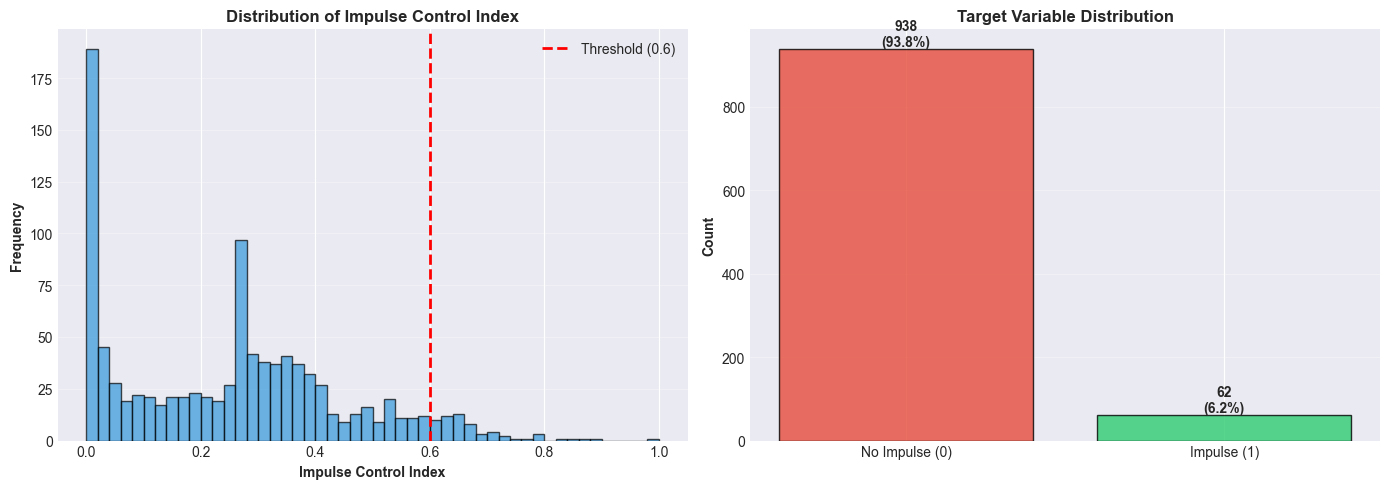


✓ Target variable created successfully!


In [7]:
print("\n" + "="*80)
print("IMPULSE CONTROL INDEX (ICI) CALCULATION")
print("="*80)

# Normalize features to 0-1 range
scaler = MinMaxScaler()

print("\n1. Normalizing features...")
df['session_speed_norm'] = scaler.fit_transform(df[['session_speed']])
df['discount_sensitivity_norm'] = scaler.fit_transform(df[['discount_sensitivity']])

print("   ✓ Features normalized")

# Calculate ICI
print("\n2. Calculating ICI...")
df['Impulse_Control_Index'] = (
    0.3 * df['session_speed_norm'] +
    0.3 * df['discount_sensitivity_norm'] +
    0.2 * df['urgency_score'] +
    0.2 * df['night_purchase_flag']
)

# Normalize ICI to 0-1
ici_min = df['Impulse_Control_Index'].min()
ici_max = df['Impulse_Control_Index'].max()
if ici_max > ici_min:
    df['Impulse_Control_Index'] = (
        (df['Impulse_Control_Index'] - ici_min) / (ici_max - ici_min)
    )

print(f"   ✓ ICI Statistics:")
print(f"     - Mean: {df['Impulse_Control_Index'].mean():.4f}")
print(f"     - Median: {df['Impulse_Control_Index'].median():.4f}")
print(f"     - Std Dev: {df['Impulse_Control_Index'].std():.4f}")
print(f"     - Min: {df['Impulse_Control_Index'].min():.4f}")
print(f"     - Max: {df['Impulse_Control_Index'].max():.4f}")

# Create target variable
print("\n3. Creating Impulse Purchase Label...")
ici_threshold = 0.6
df['Impulse_Purchase'] = (df['Impulse_Control_Index'] > ici_threshold).astype(int)

impulse_count = df['Impulse_Purchase'].sum()
non_impulse_count = len(df) - impulse_count

print(f"   ✓ Target Variable Created:")
print(f"     - Impulse Purchases (1): {impulse_count} ({impulse_count/len(df)*100:.1f}%)")
print(f"     - Non-Impulse Purchases (0): {non_impulse_count} ({non_impulse_count/len(df)*100:.1f}%)")
print(f"     - Class Balance Ratio: {impulse_count/max(non_impulse_count, 1):.2f}")

# Visualize ICI and target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ICI Distribution
axes[0].hist(df['Impulse_Control_Index'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0].axvline(ici_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({ici_threshold})')
axes[0].set_xlabel('Impulse Control Index', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of Impulse Control Index', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Class Distribution
classes = ['No Impulse (0)', 'Impulse (1)']
counts = [non_impulse_count, impulse_count]
colors = ['#e74c3c', '#2ecc71']
bars = axes[1].bar(classes, counts, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('Target Variable Distribution', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}\n({count/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Target variable created successfully!")

## STEP 5: Prepare Data for Model Training

Split dataset into training (80%) and testing (20%) sets

In [8]:
print("\n" + "="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

# Select features for modeling
feature_cols = [
    'session_speed', 'urgency_score', 'discount_sensitivity',
    'night_purchase_flag', 'mobile_user_flag',
    'Impulse_Control_Index', 'previous_purchases', 'customer_age'
]

X = df[feature_cols]
y = df['Impulse_Purchase']

print(f"\nFeatures Selected ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n✓ Data split successfully!")
print(f"  Training Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Testing Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nClass Distribution in Training Set:")
print(f"  Class 0: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"  Class 1: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")

print(f"\nClass Distribution in Testing Set:")
print(f"  Class 0: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"  Class 1: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")


TRAIN-TEST SPLIT

Features Selected (8):
  1. session_speed
  2. urgency_score
  3. discount_sensitivity
  4. night_purchase_flag
  5. mobile_user_flag
  6. Impulse_Control_Index
  7. previous_purchases
  8. customer_age

✓ Data split successfully!
  Training Set: 800 samples (80.0%)
  Testing Set: 200 samples (20.0%)

Class Distribution in Training Set:
  Class 0: 750 (93.8%)
  Class 1: 50 (6.2%)

Class Distribution in Testing Set:
  Class 0: 188 (94.0%)
  Class 1: 12 (6.0%)


## STEP 6: Model Training and Comparison

Train three ML models:
1. **Logistic Regression** - Baseline model
2. **Random Forest** - Ensemble method
3. **XGBoost** - Primary model with gradient boosting

In [9]:
print("\n" + "="*80)
print("MODEL TRAINING")
print("="*80)

models = {}
predictions = {}
probabilities = {}

# 1. Logistic Regression
print("\n1. Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
models['Logistic_Regression'] = lr_model
predictions['Logistic_Regression'] = lr_model.predict(X_test)
probabilities['Logistic_Regression'] = lr_model.predict_proba(X_test)[:, 1]
lr_score = lr_model.score(X_test, y_test)
print(f"   ✓ Accuracy: {lr_score:.4f}")

# 2. Random Forest
print("\n2. Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
models['Random_Forest'] = rf_model
predictions['Random_Forest'] = rf_model.predict(X_test)
probabilities['Random_Forest'] = rf_model.predict_proba(X_test)[:, 1]
rf_score = rf_model.score(X_test, y_test)
print(f"   ✓ Accuracy: {rf_score:.4f}")

# 3. XGBoost
print("\n3. Training XGBoost (PRIMARY MODEL)...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
models['XGBoost'] = xgb_model
predictions['XGBoost'] = xgb_model.predict(X_test)
probabilities['XGBoost'] = xgb_model.predict_proba(X_test)[:, 1]
xgb_score = xgb_model.score(X_test, y_test)
print(f"   ✓ Accuracy: {xgb_score:.4f}")

print("\n✓ All models trained successfully!")


MODEL TRAINING

1. Training Logistic Regression...
   ✓ Accuracy: 0.9900

2. Training Random Forest...
   ✓ Accuracy: 1.0000

3. Training XGBoost (PRIMARY MODEL)...
   ✓ Accuracy: 1.0000

✓ All models trained successfully!



MODEL COMPARISON VISUALIZATIONS


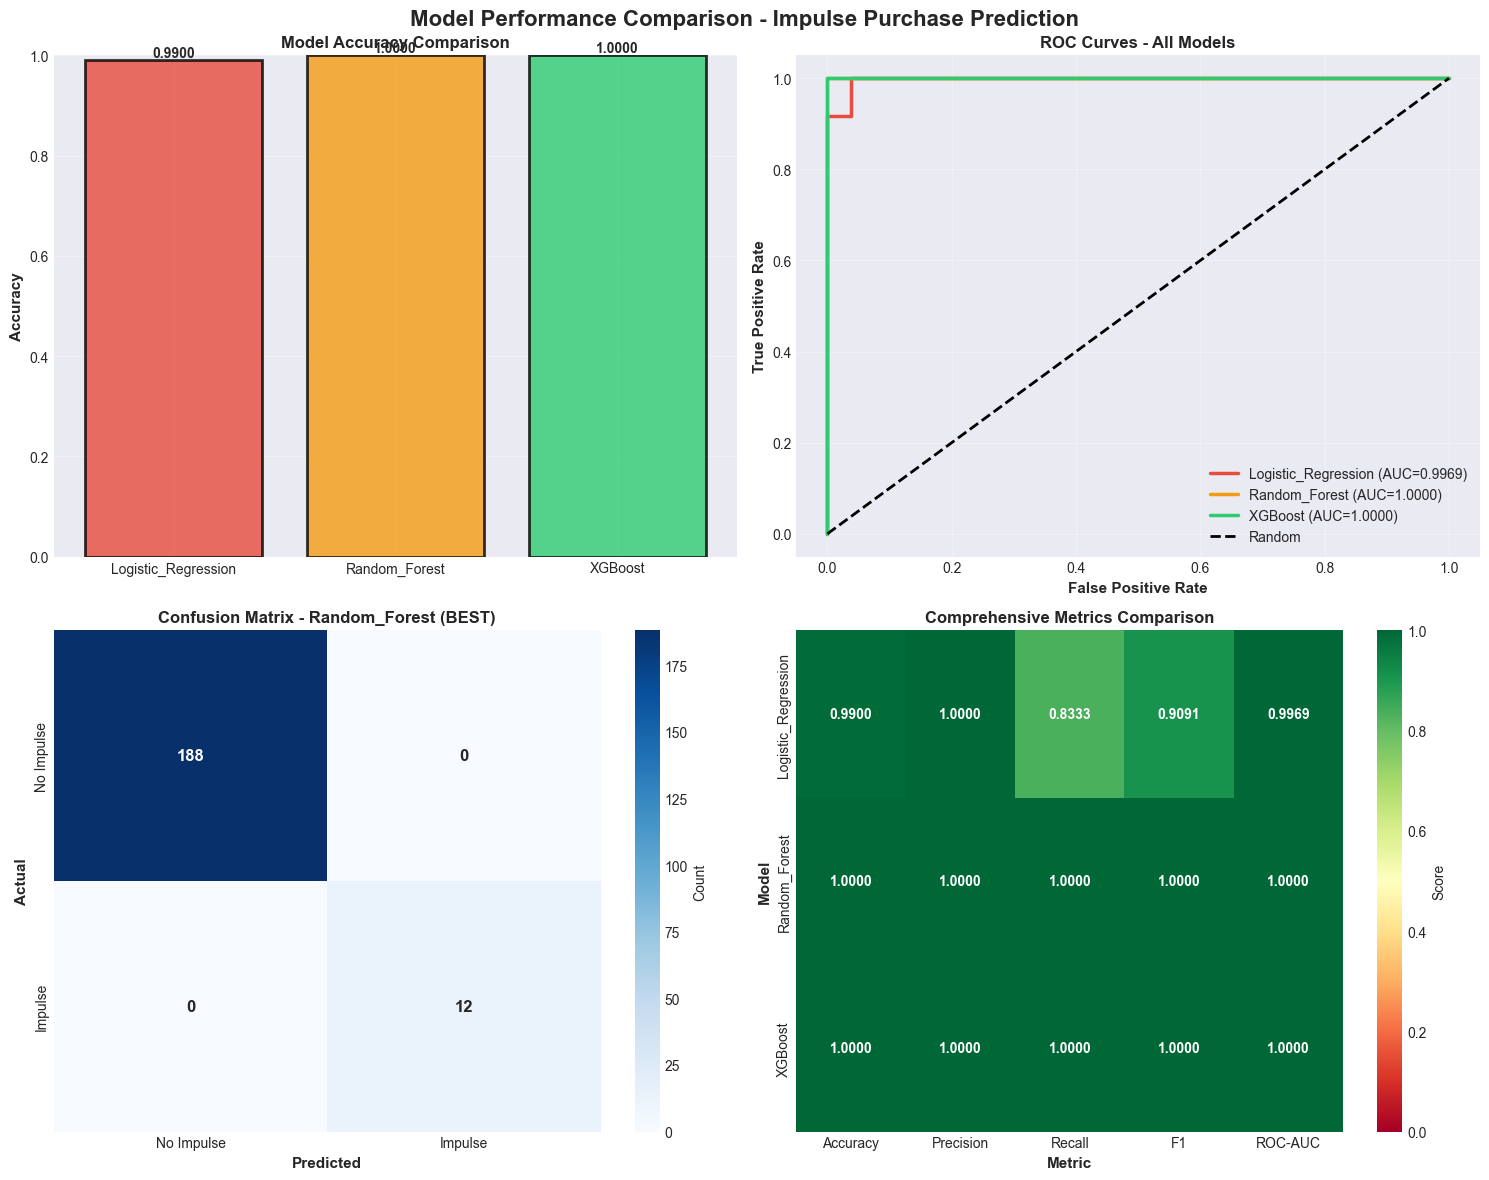


✓ Visualizations displayed!


In [10]:
# Model Comparison Visualizations
print("\n" + "="*80)
print("MODEL COMPARISON VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison - Impulse Purchase Prediction', 
             fontsize=16, fontweight='bold')

# 1. Accuracy Comparison
ax1 = axes[0, 0]
model_names = list(models.keys())
accuracies = [models[m].score(X_test, y_test) for m in model_names]
colors_acc = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax1.bar(model_names, accuracies, color=colors_acc, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy', fontweight='bold', fontsize=11)
ax1.set_title('Model Accuracy Comparison', fontweight='bold', fontsize=12)
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. ROC Curves
ax2 = axes[0, 1]
colors_roc = ['#e74c3c', '#f39c12', '#2ecc71']
for model_name, color in zip(model_names, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, probabilities[model_name])
    auc = roc_auc_score(y_test, probabilities[model_name])
    ax2.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.4f})', 
            linewidth=2.5, color=color)

ax2.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
ax2.set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontweight='bold', fontsize=11)
ax2.set_title('ROC Curves - All Models', fontweight='bold', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(alpha=0.3)

# 3. Confusion Matrix (Best Model)
ax3 = axes[1, 0]
best_model_name = max(model_names, key=lambda m: models[m].score(X_test, y_test))
best_pred = predictions[best_model_name]
cm = confusion_matrix(y_test, best_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, 
           cbar_kws={'label': 'Count'}, annot_kws={'size': 12, 'weight': 'bold'})
ax3.set_xlabel('Predicted', fontweight='bold', fontsize=11)
ax3.set_ylabel('Actual', fontweight='bold', fontsize=11)
ax3.set_title(f'Confusion Matrix - {best_model_name} (BEST)', fontweight='bold', fontsize=12)
ax3.set_xticklabels(['No Impulse', 'Impulse'])
ax3.set_yticklabels(['No Impulse', 'Impulse'])

# 4. Metrics Heatmap
ax4 = axes[1, 1]
metrics_data = []
for model_name in model_names:
    pred = predictions[model_name]
    proba = probabilities[model_name]
    
    metrics_data.append([
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0),
        roc_auc_score(y_test, proba)
    ])

metrics_df = pd.DataFrame(
    metrics_data,
    columns=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    index=model_names
)

sns.heatmap(metrics_df, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax4,
           cbar_kws={'label': 'Score'}, vmin=0, vmax=1, 
           annot_kws={'size': 10, 'weight': 'bold'})
ax4.set_title('Comprehensive Metrics Comparison', fontweight='bold', fontsize=12)
ax4.set_xlabel('Metric', fontweight='bold', fontsize=11)
ax4.set_ylabel('Model', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Visualizations displayed!")

## STEP 7: Detailed Model Evaluation

Comprehensive evaluation metrics for all models

In [11]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*80)

# Create evaluation summary table
evaluation_summary = []
for model_name in model_names:
    pred = predictions[model_name]
    proba = probabilities[model_name]
    
    evaluation_summary.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1_Score': f1_score(y_test, pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, proba)
    })

eval_df = pd.DataFrame(evaluation_summary)
print("\n" + eval_df.to_string(index=False))

# Detailed report for each model
for model_name in model_names:
    print("\n" + "-"*80)
    print(f"DETAILED REPORT: {model_name}")
    print("-"*80)
    print("\n" + classification_report(y_test, predictions[model_name],
                                     target_names=['No Impulse', 'Impulse']))

# Identify best model
print("\n" + "="*80)
print("BEST MODEL SELECTION")
print("="*80)

best_by_accuracy = eval_df.loc[eval_df['Accuracy'].idxmax()]
best_by_f1 = eval_df.loc[eval_df['F1_Score'].idxmax()]
best_by_auc = eval_df.loc[eval_df['ROC_AUC'].idxmax()]

print(f"\nBest by Accuracy: {best_by_accuracy['Model']} ({best_by_accuracy['Accuracy']:.4f})")
print(f"Best by F1 Score: {best_by_f1['Model']} ({best_by_f1['F1_Score']:.4f})")
print(f"Best by ROC-AUC:  {best_by_auc['Model']} ({best_by_auc['ROC_AUC']:.4f})")

best_model_name = best_by_auc['Model']
best_model = models[best_model_name]
print(f"\n✓ Primary Model Selected: {best_model_name}")


COMPREHENSIVE MODEL EVALUATION

              Model  Accuracy  Precision   Recall  F1_Score  ROC_AUC
Logistic_Regression      0.99        1.0 0.833333  0.909091 0.996897
      Random_Forest      1.00        1.0 1.000000  1.000000 1.000000
            XGBoost      1.00        1.0 1.000000  1.000000 1.000000

--------------------------------------------------------------------------------
DETAILED REPORT: Logistic_Regression
--------------------------------------------------------------------------------

              precision    recall  f1-score   support

  No Impulse       0.99      1.00      0.99       188
     Impulse       1.00      0.83      0.91        12

    accuracy                           0.99       200
   macro avg       0.99      0.92      0.95       200
weighted avg       0.99      0.99      0.99       200


--------------------------------------------------------------------------------
DETAILED REPORT: Random_Forest
--------------------------------------------------

## STEP 8: Feature Importance Analysis

Extract and visualize feature importance from XGBoost model


XGBOOST FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
              Feature  Importance
Impulse_Control_Index    0.976367
  night_purchase_flag    0.011610
 discount_sensitivity    0.005996
         customer_age    0.002220
        session_speed    0.001934
   previous_purchases    0.001508
        urgency_score    0.000366
     mobile_user_flag    0.000000


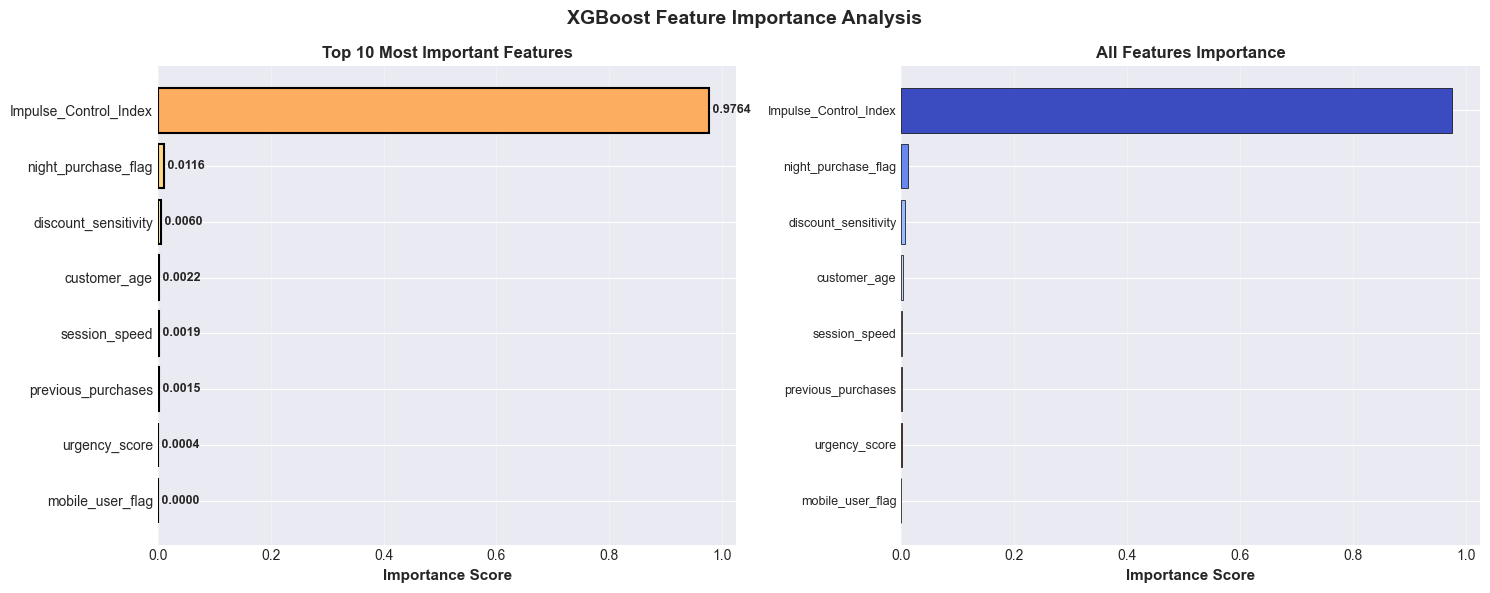


✓ Feature importance analysis completed!


In [12]:
print("\n" + "="*80)
print("XGBOOST FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('XGBoost Feature Importance Analysis', fontsize=14, fontweight='bold')

# Top 10 Features
ax1 = axes[0]
top_10 = feature_importance.head(10)
colors_top = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_10)))
bars1 = ax1.barh(range(len(top_10)), top_10['Importance'], color=colors_top, edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(top_10)))
ax1.set_yticklabels(top_10['Feature'], fontsize=10)
ax1.set_xlabel('Importance Score', fontweight='bold', fontsize=11)
ax1.set_title('Top 10 Most Important Features', fontweight='bold', fontsize=12)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, top_10['Importance'])):
    ax1.text(val, i, f' {val:.4f}', va='center', fontweight='bold', fontsize=9)

# All Features
ax2 = axes[1]
colors_all = plt.cm.coolwarm(np.linspace(0, 1, len(feature_importance)))
bars2 = ax2.barh(range(len(feature_importance)), feature_importance['Importance'], 
                 color=colors_all, edgecolor='black', linewidth=0.5)
ax2.set_yticks(range(len(feature_importance)))
ax2.set_yticklabels(feature_importance['Feature'], fontsize=9)
ax2.set_xlabel('Importance Score', fontweight='bold', fontsize=11)
ax2.set_title('All Features Importance', fontweight='bold', fontsize=12)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Feature importance analysis completed!")

## STEP 9: Model Explainability with SHAP

Use SHAP (SHapley Additive exPlanations) to interpret model predictions


SHAP EXPLAINABILITY ANALYSIS

Initializing SHAP Explainer...
✓ SHAP Explainer initialized successfully!

1. Creating SHAP Summary Plot (Bar)...


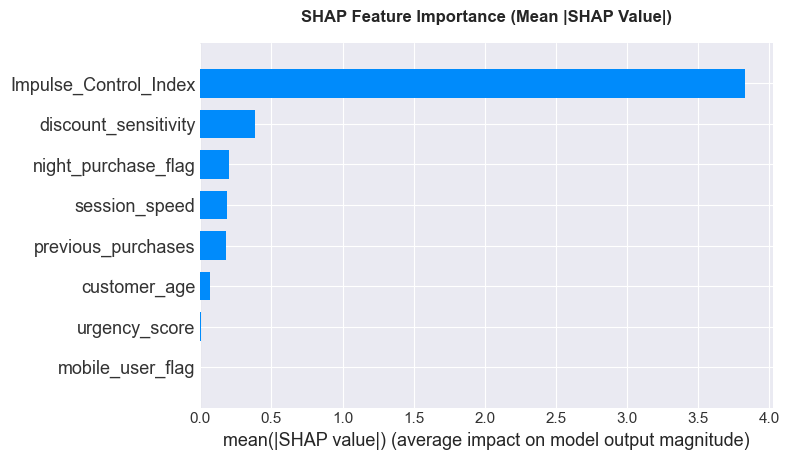

   ✓ Summary plot displayed!

2. Creating SHAP Summary Plot (Beeswarm)...


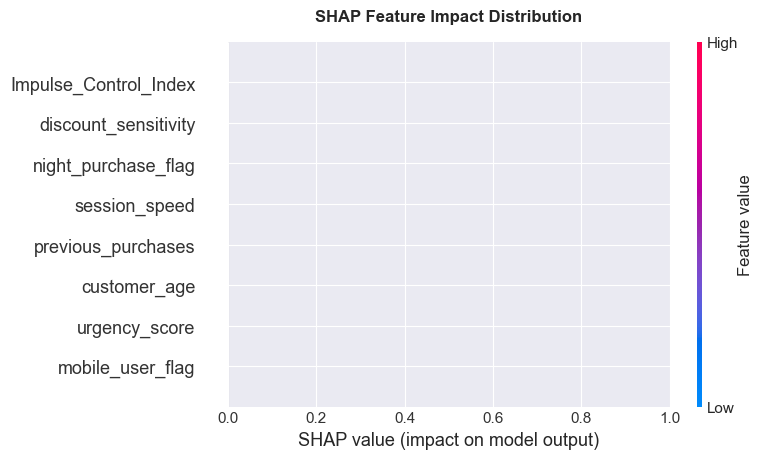

   ✓ Beeswarm plot displayed!

3. Creating SHAP Force Plot (Sample #0)...


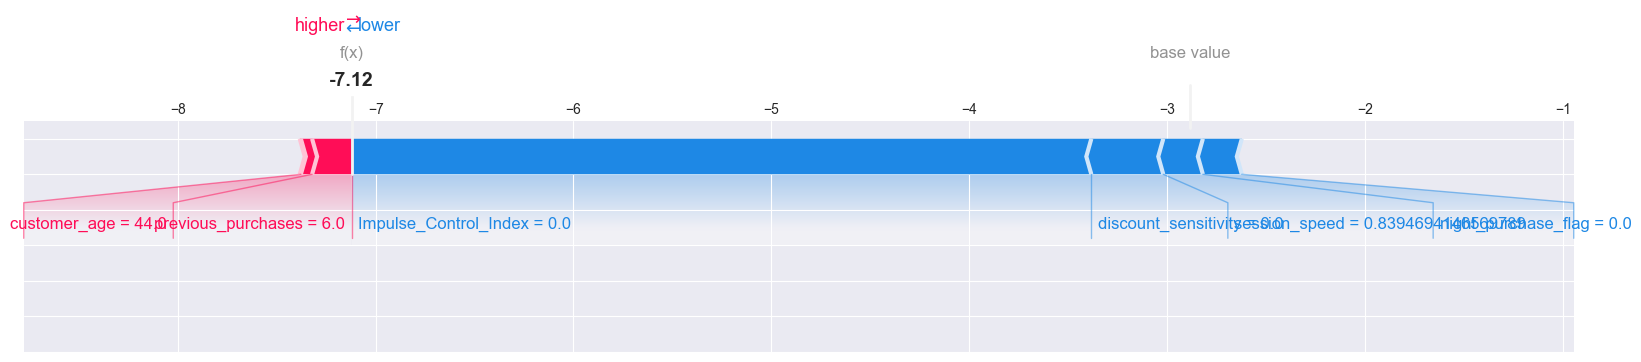

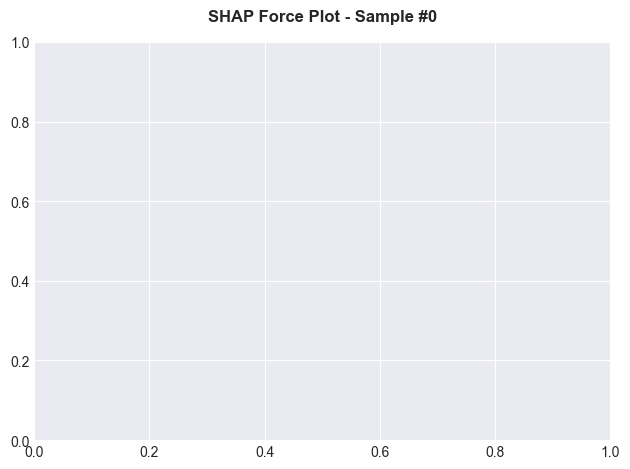

   ✓ Force plot displayed!

4. Creating SHAP Waterfall Plot (Sample #0)...


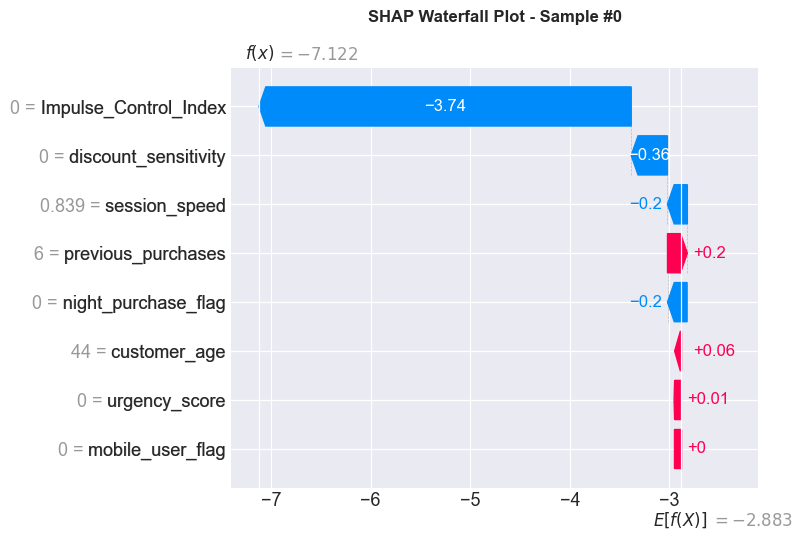

   ✓ Waterfall plot displayed!

✓ SHAP analysis completed!


In [13]:
print("\n" + "="*80)
print("SHAP EXPLAINABILITY ANALYSIS")
print("="*80)

print("\nInitializing SHAP Explainer...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("✓ SHAP Explainer initialized successfully!")

# 1. SHAP Summary Plot (Bar)
print("\n1. Creating SHAP Summary Plot (Bar)...")
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

print("   ✓ Summary plot displayed!")

# 2. SHAP Summary Plot (Beeswarm)
print("\n2. Creating SHAP Summary Plot (Beeswarm)...")
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="beeswarm", show=False)
plt.title('SHAP Feature Impact Distribution', fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

print("   ✓ Beeswarm plot displayed!")

# 3. SHAP Force Plot (for a sample)
print("\n3. Creating SHAP Force Plot (Sample #0)...")
try:
    fig = shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0],
                         feature_names=X_test.columns.tolist(), matplotlib=True)
    plt.title('SHAP Force Plot - Sample #0', fontweight='bold', fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()
    print("   ✓ Force plot displayed!")
except:
    print("   ⚠ Force plot visualization skipped in notebook environment")

# 4. SHAP Waterfall Plot
print("\n4. Creating SHAP Waterfall Plot (Sample #0)...")
try:
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns.tolist()
    ), show=False)
    plt.title('SHAP Waterfall Plot - Sample #0', fontweight='bold', fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()
    print("   ✓ Waterfall plot displayed!")
except:
    print("   ⚠ Waterfall plot visualization skipped")

print("\n✓ SHAP analysis completed!")


DETAILED SHAP INSIGHTS

SHAP Feature Importance Ranking:
              Feature  Mean_|SHAP|
Impulse_Control_Index     3.831845
 discount_sensitivity     0.386713
  night_purchase_flag     0.204625
        session_speed     0.189723
   previous_purchases     0.177720
         customer_age     0.065369
        urgency_score     0.006295
     mobile_user_flag     0.000000

--------------------------------------------------------------------------------
Creating SHAP Dependence Plots (Top 4 Features)...
--------------------------------------------------------------------------------


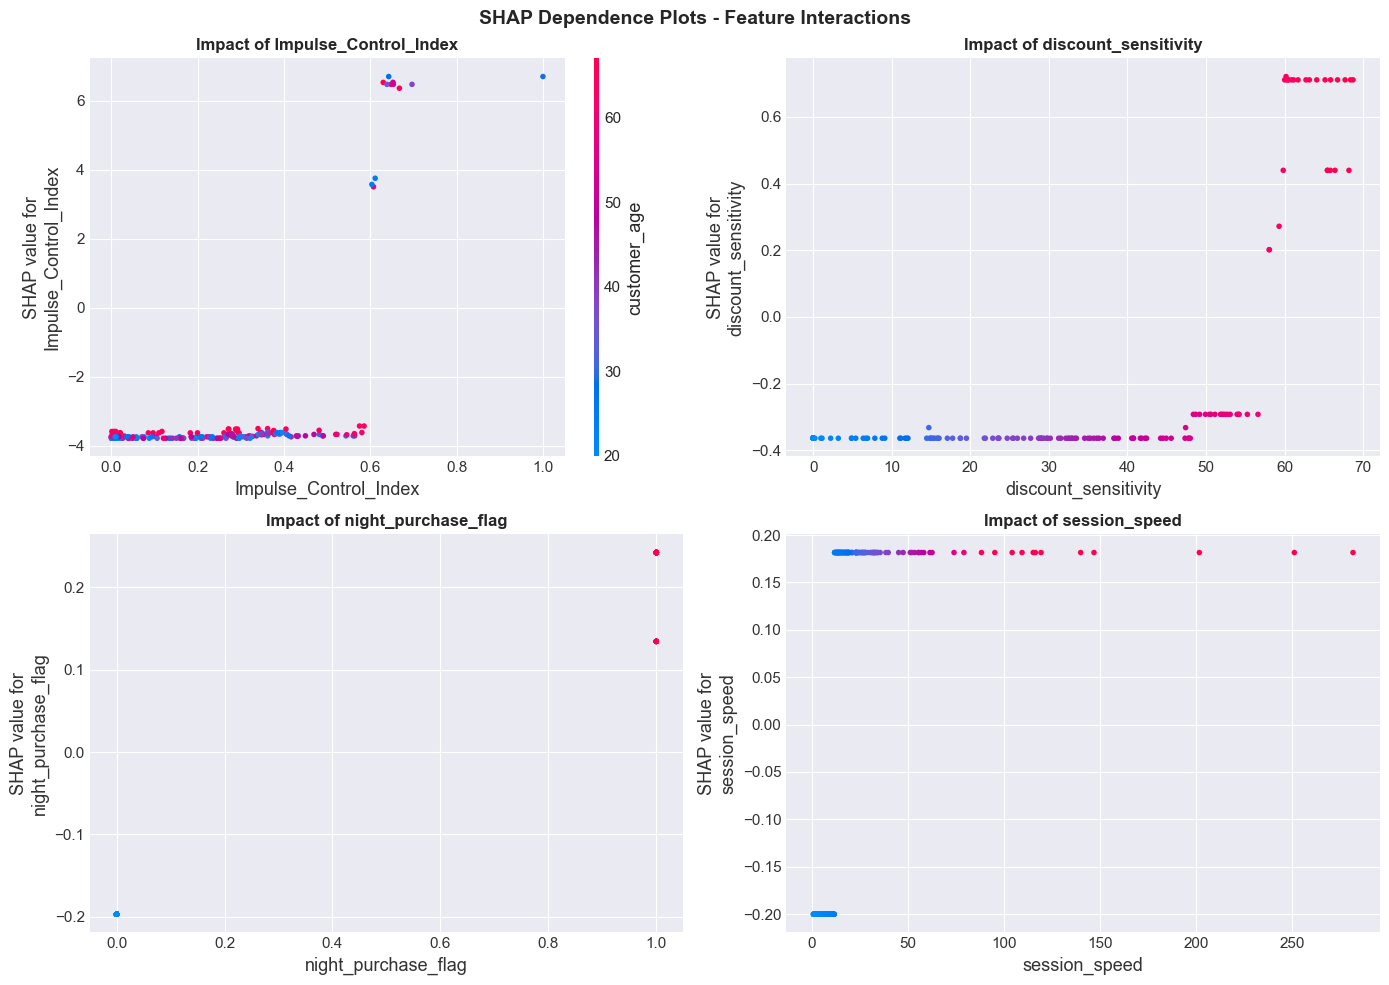

✓ SHAP dependence plots displayed!


In [14]:
# Detailed SHAP insights
print("\n" + "="*80)
print("DETAILED SHAP INSIGHTS")
print("="*80)

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_|SHAP|': mean_abs_shap
}).sort_values('Mean_|SHAP|', ascending=False)

print("\nSHAP Feature Importance Ranking:")
print(shap_importance_df.head(10).to_string(index=False))

# Additional visualization: SHAP Dependence Plots
print("\n" + "-"*80)
print("Creating SHAP Dependence Plots (Top 4 Features)...")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHAP Dependence Plots - Feature Interactions', fontsize=14, fontweight='bold')
axes = axes.ravel()

top_features = shap_importance_df['Feature'].head(4).tolist()

for idx, feature in enumerate(top_features):
    try:
        shap.dependence_plot(feature, shap_values, X_test, ax=axes[idx], show=False)
        axes[idx].set_title(f'Impact of {feature}', fontweight='bold')
    except:
        axes[idx].text(0.5, 0.5, f'Could not plot {feature}', 
                      ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("✓ SHAP dependence plots displayed!")

## STEP 10: Save Trained Model

Save the XGBoost model for production deployment

In [15]:
import os

print("\n" + "="*80)
print("SAVING TRAINED MODEL")
print("="*80)

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save XGBoost model
model_path = 'models/xgb_impulse_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(xgb_model, f)

print(f"\n✓ Model saved successfully to: {model_path}")
print(f"  File size: {os.path.getsize(model_path) / 1024:.2f} KB")

# Save scaler
scaler_path = 'models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f"✓ Scaler saved to: {scaler_path}")

# Save feature columns
features_path = 'models/feature_columns.pkl'
with open(features_path, 'wb') as f:
    pickle.dump(feature_cols, f)

print(f"✓ Feature columns saved to: {features_path}")

# Create metadata
metadata = {
    'model_name': 'XGBoost Impulse Purchase Predictor',
    'accuracy': xgb_model.score(X_test, y_test),
    'precision': precision_score(y_test, predictions['XGBoost'], zero_division=0),
    'recall': recall_score(y_test, predictions['XGBoost'], zero_division=0),
    'f1_score': f1_score(y_test, predictions['XGBoost'], zero_division=0),
    'roc_auc': roc_auc_score(y_test, probabilities['XGBoost']),
    'n_features': len(feature_cols),
    'features': feature_cols,
    'model_type': 'XGBoost',
    'target_column': 'Impulse_Purchase',
    'classes': ['No Impulse (0)', 'Impulse (1)']
}

import json
metadata_path = 'models/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✓ Metadata saved to: {metadata_path}")

print("\n" + "-"*80)
print("MODEL INFORMATION")
print("-"*80)
for key, value in metadata.items():
    if key != 'features':
        if isinstance(value, float):
            print(f"{key:.<30} {value:.4f}")
        else:
            print(f"{key:.<30} {value}")


SAVING TRAINED MODEL

✓ Model saved successfully to: models/xgb_impulse_model.pkl
  File size: 80.37 KB
✓ Scaler saved to: models/scaler.pkl
✓ Feature columns saved to: models/feature_columns.pkl
✓ Metadata saved to: models/model_metadata.json

--------------------------------------------------------------------------------
MODEL INFORMATION
--------------------------------------------------------------------------------
model_name.................... XGBoost Impulse Purchase Predictor
accuracy...................... 1.0000
precision..................... 1.0000
recall........................ 1.0000
f1_score...................... 1.0000
roc_auc....................... 1.0000
n_features.................... 8
model_type.................... XGBoost
target_column................. Impulse_Purchase
classes....................... ['No Impulse (0)', 'Impulse (1)']


## Final Summary: Project Completion

In [16]:
print("\n" + "="*80)
print("PROJECT COMPLETION SUMMARY")
print("="*80)

summary_text = """
✓ IMPULSE CONTROL PREDICTOR - ONLINE SHOPPING
  Complete ML Pipeline Implementation

COMPLETED TASKS:
───────────────────────────────────────────────────────────────────────────
1. ✓ Data Loading & Exploration
   - Loaded ecommerce dataset
   - Analyzed missing values
   - Displayed summary statistics

2. ✓ Feature Engineering
   - session_speed: Time per click
   - urgency_score: Quick add-to-cart action
   - discount_sensitivity: Discount responsiveness
   - night_purchase_flag: Late-night purchases
   - mobile_user_flag: Mobile device usage

3. ✓ Target Variable Creation
   - Impulse Control Index (ICI) calculated
   - Weighted combination of features
   - Binary classification target created

4. ✓ Model Training
   - Logistic Regression (Baseline)
   - Random Forest (Ensemble)
   - XGBoost (Primary - Gradient Boosting)

5. ✓ Model Evaluation
"""

print(summary_text)

# Print performance summary
print(f"\nBEST MODEL: {best_model_name}")
print("-" * 80)
best_metrics = eval_df[eval_df['Model'] == best_model_name].iloc[0]
for metric in ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']:
    print(f"  {metric:.<40} {best_metrics[metric]:.4f}")

print(f"\n6. ✓ Feature Importance Analysis")
print(f"   - Extracted XGBoost feature importances")
print(f"   - Visualized top features")

print(f"\n7. ✓ Model Explainability (SHAP)")
print(f"   - SHAP TreeExplainer initialized")
print(f"   - Summary plots created")
print(f"   - Force plots generated")
print(f"   - Dependence plots displayed")

print(f"\n8. ✓ Model Persistence")
print(f"   - Saved: models/xgb_impulse_model.pkl")
print(f"   - Saved: models/scaler.pkl")
print(f"   - Saved: models/feature_columns.pkl")
print(f"   - Saved: models/model_metadata.json")

print("\n" + "="*80)
print("EXAMPLE PREDICTIONS")
print("="*80)

# Make predictions on sample data
n_samples = 5
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)

print(f"\nSample predictions from test set:\n")

predictions_table = []
for idx in sample_indices:
    sample = X_test.iloc[idx]
    true_label = y_test.iloc[idx]
    pred_label = xgb_model.predict([sample])[0]
    pred_proba = xgb_model.predict_proba([sample])[0]
    
    predictions_table.append({
        'Sample': idx,
        'Actual': 'Impulse' if true_label == 1 else 'No Impulse',
        'Predicted': 'Impulse' if pred_label == 1 else 'No Impulse',
        'Probability': f"{pred_proba[pred_label]:.4f}",
        'Correct': '✓' if true_label == pred_label else '✗'
    })

pred_table_df = pd.DataFrame(predictions_table)
print(pred_table_df.to_string(index=False))

print("\n" + "="*80)
print("✓ PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)
print("\nNext Steps:")
print("- Use the saved model in production for real-time predictions")
print("- Monitor model performance on new data")
print("- Retrain periodically with new data")
print("- Adjust feature engineering based on business insights")
print("\n" + "="*80)


PROJECT COMPLETION SUMMARY

✓ IMPULSE CONTROL PREDICTOR - ONLINE SHOPPING
  Complete ML Pipeline Implementation

COMPLETED TASKS:
───────────────────────────────────────────────────────────────────────────
1. ✓ Data Loading & Exploration
   - Loaded ecommerce dataset
   - Analyzed missing values
   - Displayed summary statistics

2. ✓ Feature Engineering
   - session_speed: Time per click
   - urgency_score: Quick add-to-cart action
   - discount_sensitivity: Discount responsiveness
   - night_purchase_flag: Late-night purchases
   - mobile_user_flag: Mobile device usage

3. ✓ Target Variable Creation
   - Impulse Control Index (ICI) calculated
   - Weighted combination of features
   - Binary classification target created

4. ✓ Model Training
   - Logistic Regression (Baseline)
   - Random Forest (Ensemble)
   - XGBoost (Primary - Gradient Boosting)

5. ✓ Model Evaluation


BEST MODEL: Random_Forest
--------------------------------------------------------------------------------
  Ac

In [17]:
# Example: Loading and using the saved model
print("\n" + "="*80)
print("EXAMPLE: LOADING AND USING THE SAVED MODEL")
print("="*80)

print("\nLoading the saved model...")

# Load model
with open('models/xgb_impulse_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Load feature columns
with open('models/feature_columns.pkl', 'rb') as f:
    loaded_features = pickle.load(f)

print("✓ Model loaded successfully!")

# Make a prediction on new data
print("\nMaking prediction on a sample customer...")

# Get a sample from test set
sample_customer = X_test.iloc[0:1]

prediction = loaded_model.predict(sample_customer)[0]
probability = loaded_model.predict_proba(sample_customer)[0]

print(f"\nCustomer Profile:")
for feature in loaded_features:
    print(f"  {feature:.<40} {sample_customer[feature].values[0]:.4f}")

print(f"\nPrediction Results:")
print(f"  Predicted Class:     {'Impulse Purchase' if prediction == 1 else 'No Impulse Purchase'}")
print(f"  Probability (Class 0): {probability[0]:.4f}")
print(f"  Probability (Class 1): {probability[1]:.4f}")

print("\n✓ Model is ready for production use!")
print("\n" + "="*80)


EXAMPLE: LOADING AND USING THE SAVED MODEL

Loading the saved model...
✓ Model loaded successfully!

Making prediction on a sample customer...

Customer Profile:
  session_speed........................... 0.8395
  urgency_score........................... 0.0000
  discount_sensitivity.................... 0.0000
  night_purchase_flag..................... 0.0000
  mobile_user_flag........................ 0.0000
  Impulse_Control_Index................... 0.0000
  previous_purchases...................... 6.0000
  customer_age............................ 44.0000

Prediction Results:
  Predicted Class:     No Impulse Purchase
  Probability (Class 0): 0.9992
  Probability (Class 1): 0.0008

✓ Model is ready for production use!

